In [ ]:
!pip install --quiet transformers huggingface_hub bitsandbytes accelerate sentencepiece gradio

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
)

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/US_Airways.csv'  # adjust if it's in a subfolder
df = pd.read_csv(file_path)

In [ ]:
# libraries for data manipulation
import pandas as pd
import numpy as np

# libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# importing LLM models and tokenizers
from transformers import T5Tokenizer, T5ForConditionalGeneration

# importing metric functions
from sklearn.metrics import confusion_matrix, accuracy_score

# importing library to split the data
from sklearn.model_selection import train_test_split

# library for model deployment
import gradio as gr

In [ ]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570310600460525568,negative,0.6292,Flight Booking Problems,0.3146,US Airways,NaN,jhazelnut,NaN,0,@USAirways is there a better time to call? My...,NaN,2015-02-24 11:53:37 -0800,NaN,NaN
1,570310144459972608,negative,1.0000,Customer Service Issue,1.0000,US Airways,NaN,GAKotsch,NaN,0,@USAirways and when will one of these agents b...,NaN,2015-02-24 11:51:48 -0800,NaN,Atlantic Time (Canada)
2,570309340952993796,neutral,1.0000,NaN,NaN,US Airways,NaN,DebbiMcGinnis,NaN,0,@USAirways is a DM possible if you aren't foll...,NaN,2015-02-24 11:48:37 -0800,Missourah,Hawaii
3,570309000279023616,neutral,1.0000,NaN,NaN,US Airways,NaN,AshleyKAtherton,NaN,0,@USAirways Fortunately you have staff like Lyn...,NaN,2015-02-24 11:47:16 -0800,NaN,Central Time (US & Canada)
4,570308799950692353,negative,1.0000,Customer Service Issue,0.6452,US Airways,NaN,retardedlarry,NaN,0,@USAirways just hung up on me again. Another ...,NaN,2015-02-24 11:46:28 -0800,NaN,NaN


In [ ]:
df.sample(10, random_state=1)

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
1825,568873459901702145,negative,0.6675,Can't Tell,0.6675,US Airways,NaN,ScottKat22,NaN,0,@USAirways have checked all day. CHO needs ad...,NaN,2015-02-20 12:42:56 -0800,NaN,Eastern Time (US & Canada)
616,569866081164111873,neutral,1.0000,NaN,NaN,US Airways,NaN,The_BlueAnchor,NaN,0,@USAirways will all flights out of DFW be Canc...,NaN,2015-02-23 06:27:16 -0800,"Dallas, TX",Central Time (US & Canada)
1965,568777504368005120,positive,1.0000,NaN,NaN,US Airways,NaN,NicholasBSabin,NaN,0,@USAirways I appreciate your prompt response.,NaN,2015-02-20 06:21:39 -0800,"Wendell, NC",Eastern Time (US & Canada)
785,569682454757257216,negative,1.0000,Can't Tell,1.0000,US Airways,NaN,smw04,NaN,0,@USAirways Interesting you forward compliment...,NaN,2015-02-22 18:17:36 -0800,NaN,Atlantic Time (Canada)
600,569873091763032065,negative,1.0000,Late Flight,0.6720,US Airways,NaN,ConstanceSCHERE,NaN,0,"@USAirways First the pilot was Late Flight, no...","[39.88116058, -75.24031037]",2015-02-23 06:55:07 -0800,"Boston, MA",Atlantic Time (Canada)
1282,569459455273897984,negative,1.0000,Customer Service Issue,0.6995,US Airways,NaN,ChrisWalters_WV,NaN,0,@USAirways have you ever lost luggage with an ...,NaN,2015-02-22 03:31:28 -0800,West Virginia,Central Time (US & Canada)
2410,568162061278011392,negative,1.0000,Customer Service Issue,1.0000,US Airways,NaN,BigDavew2k,NaN,0,@USAirways I tried to call your customer servi...,NaN,2015-02-18 13:36:06 -0800,NaN,NaN
2753,567800315093979138,negative,1.0000,Customer Service Issue,1.0000,US Airways,NaN,GainesJohnson,NaN,0,@USAirways I have now called 12 times in the l...,NaN,2015-02-17 13:38:38 -0800,"Charlottesville, Virginia",Central Time (US & Canada)
2469,568116602186502144,negative,0.6576,Flight Booking Problems,0.6576,US Airways,NaN,alvarez16,NaN,0,"@USAirways booked an award ticket recently, no...",NaN,2015-02-18 10:35:27 -0800,USA,Eastern Time (US & Canada)
705,569729072697352192,negative,1.0000,Customer Service Issue,0.6533,US Airways,NaN,CourtneyyKay,NaN,0,@USAirways it still says that I can't check in...,NaN,2015-02-22 21:22:50 -0800,Michigan ➡️ Florida,Eastern Time (US & Canada)


In [ ]:
# creating a copy of the data to avoid any changes to original data
data = df.copy()

In [ ]:
# checking the statistical summary of the data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
tweet_id,2913.0,5.691208e+17,7.676358e+14,5.676433e+17,5.684797e+17,5.693176e+17,5.697157e+17,5.703106e+17
airline_sentiment_confidence,2913.0,9.215784e-01,1.499961e-01,3.400000e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
negativereason_confidence,2470.0,6.871717e-01,3.078601e-01,0.000000e+00,6.223500e-01,6.777000e-01,1.000000e+00,1.000000e+00
retweet_count,2913.0,8.547889e-02,1.172269e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.400000e+01


In [ ]:
# function to create labeled barplots

def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

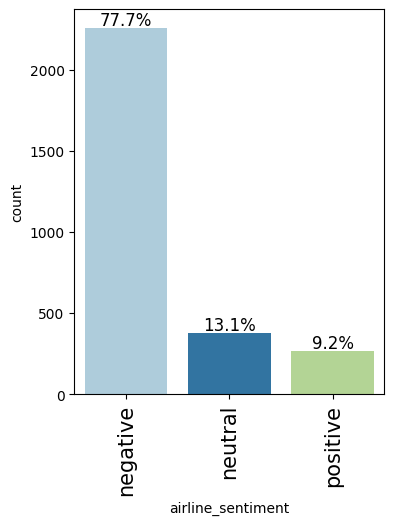

In [ ]:
labeled_barplot(data, "airline_sentiment", perc=True)

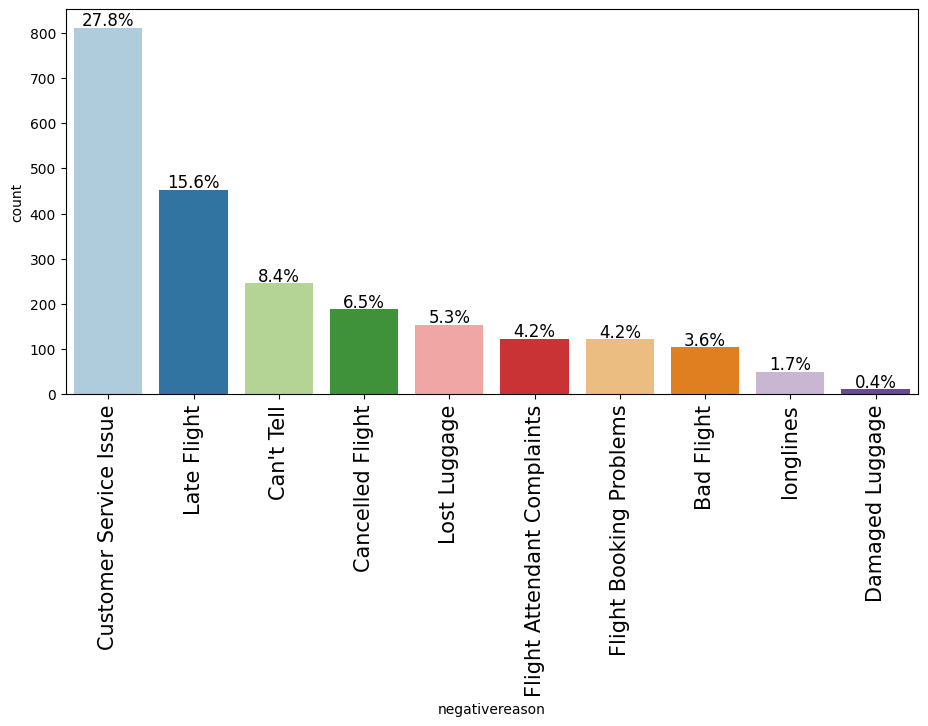

In [ ]:
labeled_barplot(data, "negativereason", perc=True)

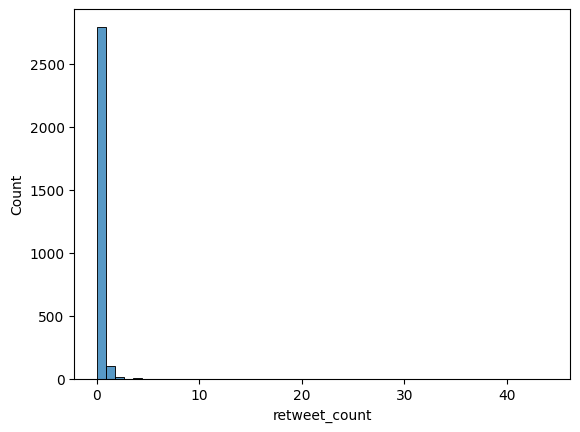

In [ ]:
sns.histplot(data, x='retweet_count', bins =50);

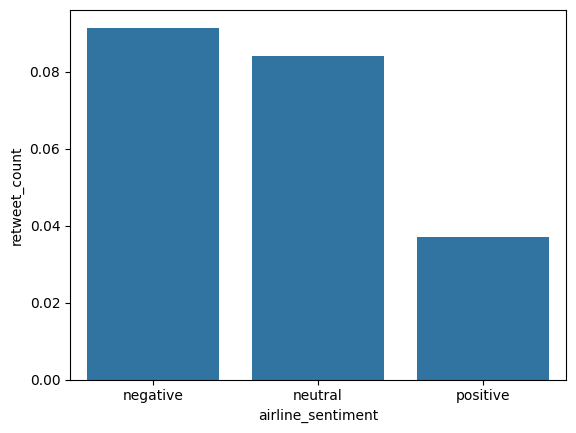

In [ ]:
sns.barplot(data, y='retweet_count', x='airline_sentiment', errorbar=('ci', False));

In [ ]:
# Specify the features (X) and the target variable (y)
X = data.drop('airline_sentiment', axis=1)  # Replace 'target_variable' with the actual name of your target column
y = data['airline_sentiment']

# Further split the temporary data into validation and test sets
X_validation, X_test, y_validation, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [ ]:
text_column_validation = X_validation['text'].copy()
actual_sentiment_validation = y_validation.copy()

In [ ]:
text_column_test = X_test['text'].copy()
actual_sentiment_test = y_test.copy()

In [ ]:
!pip install -U bitsandbytes

In [ ]:
pip install -U transformers accelerate bitsandbytes sentencepiece

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_id = "google/flan-t5-base"  # smaller & faster on CPU than -large

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForSeq2SeqLM.from_pretrained(model_id, device_map="cpu")

inputs = tokenizer("Explain quantum computing in simple terms.", return_tensors="pt")
outputs = model.generate(**inputs, max_new_tokens=64)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

quantum physics is the study of the physical properties of matter.


In [ ]:
# defining a function to generate, process, and return the LLM response
def llm_response(prompt):
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to("cuda")
    outputs = model.generate(input_ids, max_length=300, do_sample=True, temperature=0.1)
    return tokenizer.decode(outputs[0])[6:-4]

In [ ]:
# checking a customer review and it's sentiment
print(text_column_validation[4])
print(actual_sentiment_validation[4])

@USAirways just hung up on me again.  Another waste of an hour of my time.  How am I supposed to book a one way award flight?  #badwebsite
negative


In [ ]:
import os, torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

os.environ["CUDA_VISIBLE_DEVICES"] = ""     # make sure nothing tries to use CUDA
device = torch.device("cpu")

model_id = "google/flan-t5-base"            # base is faster on CPU than -large
tokenizer = AutoTokenizer.from_pretrained(model_id)

# IMPORTANT: do NOT pass load_in_8bit / 4bit or quantization_config on CPU
model = AutoModelForSeq2SeqLM.from_pretrained(
    model_id,
    torch_dtype=torch.float32,              # CPU-friendly
    device_map=None
).to(device)


`torch_dtype` is deprecated! Use `dtype` instead!


In [ ]:
def llm_response(prompt, max_new_tokens=64, temperature=0.0):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False if temperature == 0 else True,
            temperature=temperature
        )
    return tokenizer.decode(out[0], skip_special_tokens=True)


In [ ]:
def llm_response(prompt, max_new_tokens=64, temperature=0.0):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False if temperature == 0 else True,
            temperature=temperature
        )
    return tokenizer.decode(out[0], skip_special_tokens=True)


In [ ]:
sys_prompt = """
Categorize the sentiment of the customer review as positive, negative, or neutral.
Return just one word: Positive, Negative, or Neutral.
"""

pred_sent = llm_response(
    f"""
{sys_prompt}
Review text: '{text_column_validation[4]}'
"""
)

print(pred_sent)


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Negative


In [ ]:
# predicting the sentiment using the LLM
sys_prompt = """
    Categorize the sentiment of the customer review as positive, negative, or neutral.
"""

pred_sent = llm_response(
    """
        {}
        Review text: '{}'
    """.format(sys_prompt, text_column_validation[4])
)

print(pred_sent)

negative


In [ ]:
def predict_sentiment(review_text):
    pred = llm_response(
        """
            {}
            Review text: '{}'
        """.format(sys_prompt, review_text)
    )

    return pred

In [ ]:
predicted_sentiment = [predict_sentiment(item) for item in text_column_validation.values]
print(predicted_sentiment[4])

negative


In [ ]:
# combining the reviews, actual sentiments, and predicted sentiments together
df_combined = pd.concat([text_column_validation, actual_sentiment_validation], axis=1)
df_combined['predicted_sentiment'] = predicted_sentiment
df_combined.head()

,text,airline_sentiment,predicted_sentiment
439,@USAirways US 728/Feb 21. Ground power shorts ...,negative,negative
1621,@USAirways now the 3rd issue with the plane is...,negative,negative
423,@USAirways I need to speak with a customer ser...,negative,negative
2330,@USAirways delays to the max,negative,negative
1706,@USAirways Can you tell me why I waited 90 min...,negative,negative


In [ ]:
# creating confusion matrix
cnf_mt = confusion_matrix(df_combined['airline_sentiment'], df_combined['predicted_sentiment'], labels=['positive', 'neutral', 'negative'])
# computing accuracy
acc = accuracy_score(df_combined['airline_sentiment'], df_combined['predicted_sentiment'])

Accuracy: 0.8225867989317055


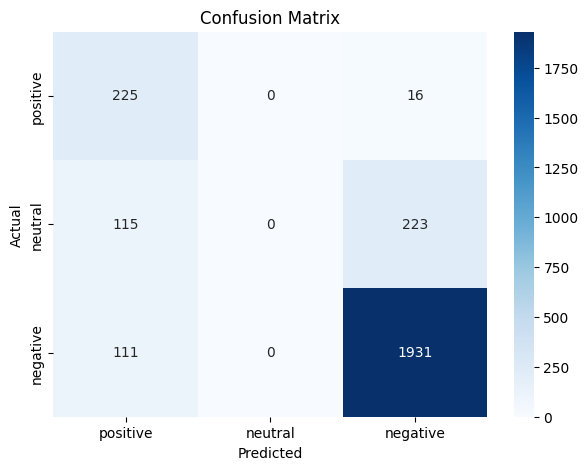

In [ ]:
# printing accuracy
print("Accuracy:", acc)

# creating a heatmap of the confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(
    cnf_mt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=['positive', 'neutral', 'negative'],
    yticklabels=['positive', 'neutral', 'negative'],
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# **Model Tuning**

In [ ]:
sys_prompt = """
    Categorize the sentiment of the customer review as positive, negative, or neutral.
    Leverage your expertise in the aviation industry and deep understanding of industry trends to analyze the nuanced expressions and overall tone.
    It is crucial to accurately identify neutral sentiments, which may indicate a balanced view or neutral stance towards Us Airways. Neutral expressions could involve factual statements without explicit positive or negative opinions.
    Consider the importance of these neutral sentiments in gauging the public sentiment towards the airline company.
    For instance, a positive sentiment might convey satisfaction with the airline's services, a negative sentiment could express dissatisfaction, while neutral sentiment may reflect an impartial observation or a neutral standpoint
"""

In [ ]:
pred_sent = llm_response(
    """
        {}
        Review text: '{}'
    """.format(sys_prompt, text_column_validation[4])
)

print(pred_sent)

negative


In [ ]:
predicted_sentiment_tuned = [predict_sentiment(item) for item in text_column_validation.values]
print(predicted_sentiment_tuned[4])

negative


In [ ]:
# combining the reviews, actual sentiments, and predicted sentiments together
df_combined = pd.concat([text_column_validation, actual_sentiment_validation], axis=1)
df_combined['predicted_sentiment'] = predicted_sentiment_tuned
df_combined.head()

,text,airline_sentiment,predicted_sentiment
439,@USAirways US 728/Feb 21. Ground power shorts ...,negative,negative
1621,@USAirways now the 3rd issue with the plane is...,negative,negative
423,@USAirways I need to speak with a customer ser...,negative,negative
2330,@USAirways delays to the max,negative,negative
1706,@USAirways Can you tell me why I waited 90 min...,negative,negative


In [ ]:
# creating confusion matrix
cnf_mt_tuned = confusion_matrix(df_combined['airline_sentiment'], df_combined['predicted_sentiment'], labels=['positive', 'neutral', 'negative'])
# computing accuracy
acc_tuned = accuracy_score(df_combined['airline_sentiment'], df_combined['predicted_sentiment'])

Accuracy: 0.8359404807325448


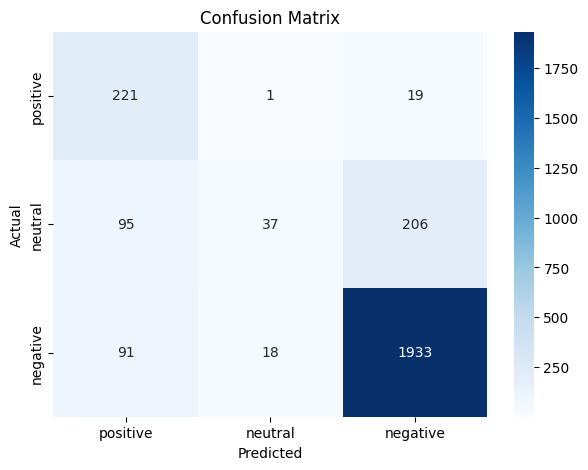

In [ ]:
# printing accuracy
print("Accuracy:", acc_tuned)

# creating a heatmap of the confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(
    cnf_mt_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=['positive', 'neutral', 'negative'],
    yticklabels=['positive', 'neutral', 'negative'],
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# **Model Testing**

In [ ]:
predicted_sentiment_test = [predict_sentiment(item) for item in text_column_test.values]

In [ ]:
# combining the reviews, actual sentiments, and predicted sentiments together
df_combined = pd.concat([text_column_test, actual_sentiment_test], axis=1)
df_combined['predicted_sentiment'] = predicted_sentiment_test
df_combined.head()

,text,airline_sentiment,predicted_sentiment
178,@USAirways it doesn't take 6 days to respond t...,negative,negative
678,@USAirways And how do you only have 1 agent at...,negative,negative
2873,@USAirways will do. Hoping for a voucher for a...,positive,positive
2686,@USAirways and if the flight is full?,neutral,neutral
1898,@sarahpompei don't bother wasting your time! ...,negative,negative


In [ ]:
# creating confusion matrix
cnf_mt_tuned = confusion_matrix(df_combined['airline_sentiment'], df_combined['predicted_sentiment'], labels=['positive', 'neutral', 'negative'])
# computing accuracy
acc_tuned = accuracy_score(df_combined['airline_sentiment'], df_combined['predicted_sentiment'])

Accuracy: 0.8253424657534246


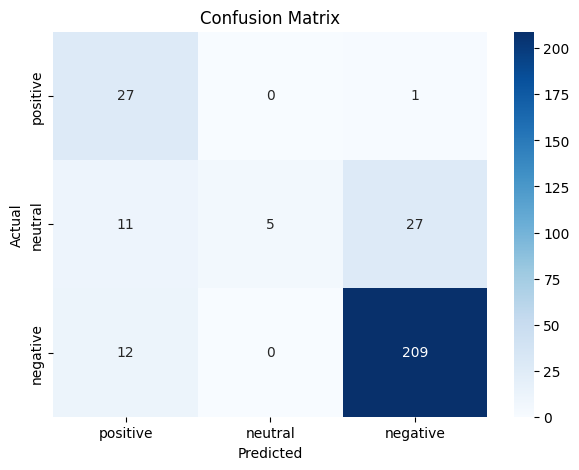

In [ ]:
# printing accuracy
print("Accuracy:", acc_tuned)

# creating a heatmap of the confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(
    cnf_mt_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=['positive', 'neutral', 'negative'],
    yticklabels=['positive', 'neutral', 'negative'],
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# **Model Deployment**

In [ ]:
# define a function that will take the necessary inputs and make predictions

def predict_review_sentiment(review):
    sys_prompt = """
        Categorize the sentiment of the customer review as positive, negative, or neutral.
        Leverage your expertise in the aviation industry and deep understanding of industry trends to analyze the nuanced expressions and overall tone.
        It is crucial to accurately identify neutral sentiments, which may indicate a balanced view or neutral stance towards Us Airways. Neutral expressions could involve factual statements without explicit positive or negative opinions.
        Consider the importance of these neutral sentiments in gauging the public sentiment towards the airline company.
        For instance, a positive sentiment might convey satisfaction with the airline's services, a negative sentiment could express dissatisfaction, while neutral sentiment may reflect an impartial observation or a neutral standpoint
    """

    # predicting the sentiment of the review
    pred_sent = llm_response(
        """
            {}
            Review text: '{}'
        """.format(sys_prompt, review)
    )

    # returning the final output
    return pred_sent

In [ ]:
# creating the deployment input interface
review_text = gr.Textbox(label="Enter the customer sentiment here.")

# creating the deployment output interface
sentiment = gr.Textbox(label="Sentiment Type")

In [ ]:
# defining the structure of the deployment interface and how the components will interact
demo = gr.Interface(
    fn=predict_review_sentiment,
    inputs = review_text,
    outputs = sentiment,
    title="Customer Review Sentiment Analyzer",
    description= "This interface will predict whether the sentiment of a customer is positive, negative, or neutral based on the review text.",
    allow_flagging="never"
)


In [ ]:
# deploying the model
demo.launch(inline=False, share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://13f9c8082097765886.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# shutting down the deployed model
demo.close()